In [ ]:
import os
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler,
    LabelEncoder,
    PowerTransformer,
    StandardScaler,
    MinMaxScaler,
    OrdinalEncoder,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
SEED = 42

# Part1: Data Understanding & Preprocessing

## 1. Load the Dataset

In [ ]:
DATA_URL ='https://github.com/datasciencedojo/datasets/raw/refs/heads/master/titanic.csv'
df = pd.read_csv(DATA_URL)

In [ ]:
rows,cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 891, Columns: 12


In [ ]:
print(f'Column names: {", ".join(df.columns)}')

Column names: PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked


In [ ]:
print("Data Types:\n",'-'*60)
display(df.info())

Data Types:
 ------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Handle Missing Values

In [ ]:
# Identify which columns have NaN (missing) values
df.isna().any(axis = 0) # axis 0 for columns / 1 for row

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,True
SibSp,False
Parch,False
Ticket,False
Fare,False


**Observation:**
* 'NaN' values are present only in the "Age", "Cabin", and "Embarked" columns.

In [ ]:
# Count Nan values each columns
df[["Age","Cabin","Embarked"]].isna().sum(axis = 0)

,0
Age,177
Cabin,687
Embarked,2


In [ ]:
# Percentage of Nan values each columns
df[["Age","Cabin","Embarked"]].isna().sum(axis = 0)/df.shape[0]

,0
Age,0.198653
Cabin,0.771044
Embarked,0.002245


**Observations:**
* The 'Cabin' column accounts for approximately 77.1% of the values; therefore, it is a crucial area requiring attention. The remaining columns to be addressed are 'Age' and 'Embarked'.

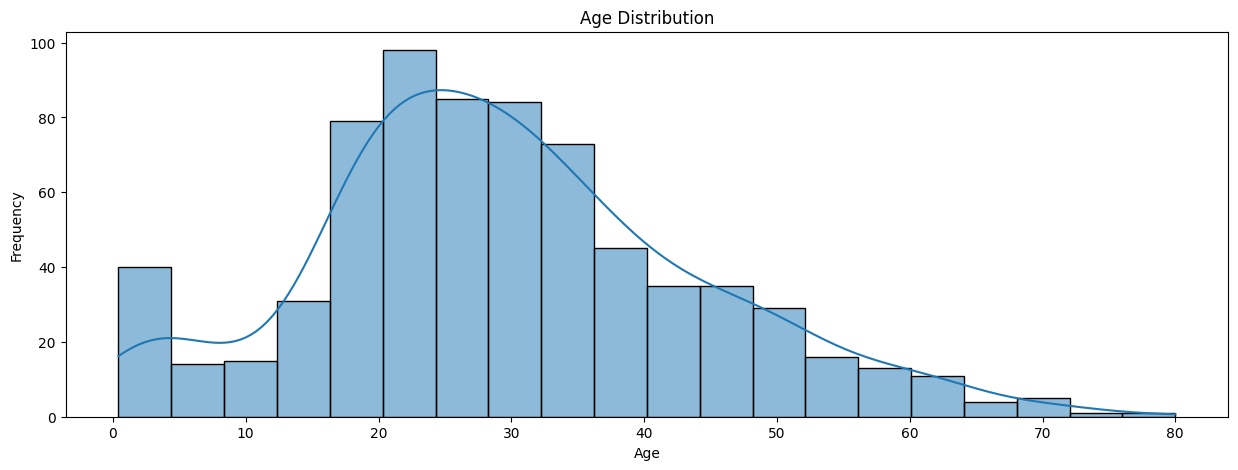

Skewness: 0.3891


In [ ]:
skewness = df['Age'].skew()
plt.figure(figsize = (15,5))
sns.histplot(df["Age"],kde = True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title("Age Distribution")
plt.show()
print(f"Skewness: {skewness:.4f}")

**Oberservations:**
* The data is slightly right-skewed; therefore, the mean cannot be used to fill in the missing values. Instead, the median can be used.

In [ ]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [ ]:
df['Cabin'].nunique()

147

**Observations:**
* There are approximately 147 unique 'cabin' values here; therefore, the simple 'mode' method cannot be used for the columns. Instead, "NaN" values can be replaced with "Missing".

In [ ]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
df['Embarked'].nunique()

3

**Observations:**
* Since this column contains a large number of unique values and very few missing values, we can use the 'mode' method for it.

## 3. Feature Selection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df['SibSp'].unique()

array([1, 0, 3, 4, 2, 5, 8])

In [ ]:
df['Parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

**Observations:**
* PassengerID serves solely to identify an individual; therefore, we will exclude it from the list of 'features'.
* 'Name' will not be considered a 'feature'; one's chances of survival cannot be predicted based on their name.
* 'Ticket' details are also not considered a suitable column for 'features'; this information merely confirms that the person registered to travel on the specific ship.
* Selected features:
    1.   Pclass (Ticket Class) - Depending on the ticket class, cabins with additional safety features might be available.
    2.   Sex (Gender) - A clear difference in survival outcomes was observed between male and female passengers, making sex an important predictive feature.
    3.   SibSp & Parch (Family Members) - Priority is always given to the elderly and children.
    4.   Fare/Cabin - A higher fare secures a cabin with superior security features.
    5.   Embarked - This is merely an optional choice; we will retain it to examine its relationship with other factors.


**Note:** Correlation has not yet been used; it will be used in the experimental section.



In [ ]:
# Selected Features
X = ['Pclass','Sex','Age','SibSp','Parch','Fare','Cabin','Embarked']
y = "Survived"

In [ ]:
# Split columns by data type wise
num_cols = df[X].select_dtypes(include=['int','float']).columns.tolist()
cat_cols = df[X].select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Columns   : {', '.join(num_cols)}")
print(f"Categorical Columns : {', '.join(cat_cols)}")
print(f"Target Column       : {y}")

Numerical Columns   : Pclass, Age, SibSp, Parch, Fare
Categorical Columns : Sex, Cabin, Embarked
Target Column       : Survived


## 4. Encode Categorical Data

In [ ]:
X_train,tmp_x,y_train,tmp_y = train_test_split(
                                df[X],df[y],test_size = 0.30,stratify = df[y],random_state = SEED)
X_test,X_val,y_test,y_val = train_test_split(
                                tmp_x,tmp_y,test_size = 0.50,stratify = tmp_y, random_state = SEED)

print("Check Data Size")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Check Data Size
Train: (623, 8)
Validation: (134, 8)
Test: (134, 8)


## 5. Feature Scaling

In [ ]:
cabins = np.asarray(['A10', 'A14', 'A16', 'A19', 'A20', 'A23', 'A24', 'A26', 'A31',
        'A32', 'A34', 'A36', 'A5', 'A6', 'A7', 'B101', 'B102', 'B18',
        'B19', 'B20', 'B22', 'B28', 'B3', 'B30', 'B35', 'B37', 'B38',
        'B39', 'B4', 'B41', 'B42', 'B49', 'B5', 'B50', 'B51 B53 B55',
        'B57 B59 B63 B66', 'B58 B60', 'B69', 'B71', 'B73', 'B77', 'B78',
        'B79', 'B80', 'B82 B84', 'B86', 'B94', 'B96 B98', 'C101', 'C103',
        'C104', 'C106', 'C110', 'C111', 'C118', 'C123', 'C124', 'C125',
        'C126', 'C128', 'C148', 'C2', 'C22 C26', 'C23 C25 C27', 'C30',
        'C32', 'C45', 'C46', 'C47', 'C49', 'C50', 'C52', 'C54', 'C62 C64',
        'C65', 'C68', 'C7', 'C70', 'C78', 'C82', 'C83', 'C85', 'C86',
        'C87', 'C90', 'C91', 'C92', 'C93', 'C95', 'C99', 'D', 'D10 D12',
        'D11', 'D15', 'D17', 'D19', 'D20', 'D21', 'D26', 'D28', 'D30',
        'D33', 'D35', 'D36', 'D37', 'D45', 'D46', 'D47', 'D48', 'D49',
        'D50', 'D56', 'D6', 'D7', 'D9', 'E10', 'E101', 'E12', 'E121',
        'E17', 'E24', 'E25', 'E31', 'E33', 'E34', 'E36', 'E38', 'E40',
        'E44', 'E46', 'E49', 'E50', 'E58', 'E63', 'E67', 'E68', 'E77',
        'E8', 'F E69', 'F G63', 'F G73', 'F2', 'F33', 'F38', 'F4', 'G6',
        'T','Missing'])
age_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

fare_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson')),
])

other_num_cols = ['Pclass', 'SibSp', 'Parch']
other_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

sex_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

cabin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ord_encoder', OrdinalEncoder(categories = [cabins],handle_unknown='error')),
    ('scaler', RobustScaler())
])

embarked_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('age', age_pipeline, ['Age']),
        ('fare', fare_pipeline, ['Fare']),
        ('num', other_num_pipeline, other_num_cols),
        ('sex', sex_pipeline, ['Sex']),
        ('cabin', cabin_pipeline, ['Cabin']),
        ('embarked', embarked_pipeline, ['Embarked'])
    ],
    remainder='drop'
)
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

print(f"Train: {X_train_processed.shape}")
print(f"Validation: {X_val_processed.shape}")
print(f"Test: {X_test_processed.shape}")

Train: (623, 11)
Validation: (134, 11)
Test: (134, 11)


**Oberservations:**
* Why is feature scaling beneficial for neural networks?

    1. Smoother gradients: Large numerical values require more time for the model to learn features. Furthermore, activation functions tend to push large values into a "flat" region where the gradient becomes zero.

    2. Faster training: Generally, large numbers consume more memory resources on RAM. Therefore, scaled values significantly accelerate the training process.


# Part 2 : Basic Exploratory Data Analysis

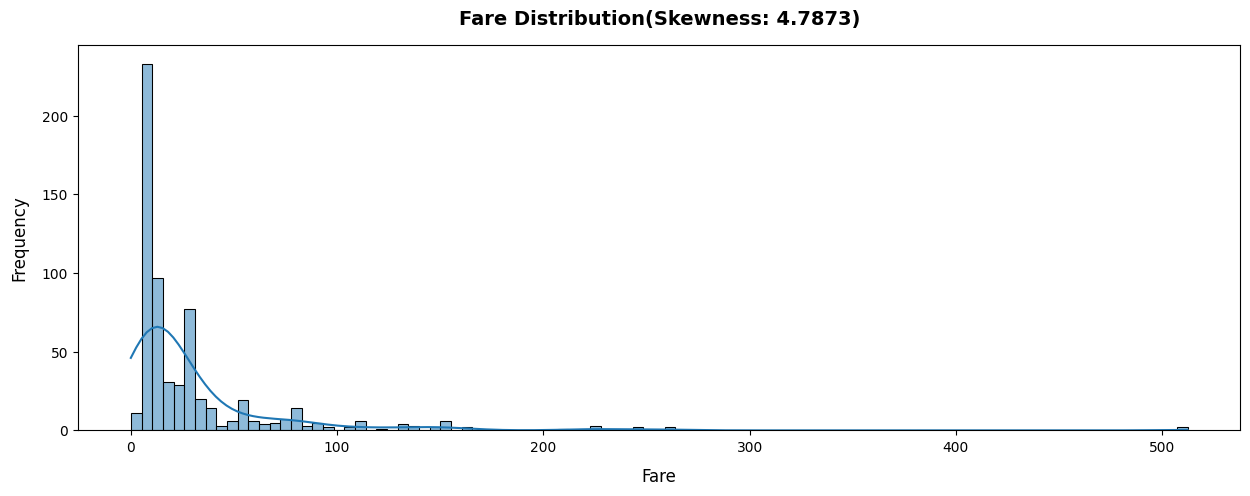

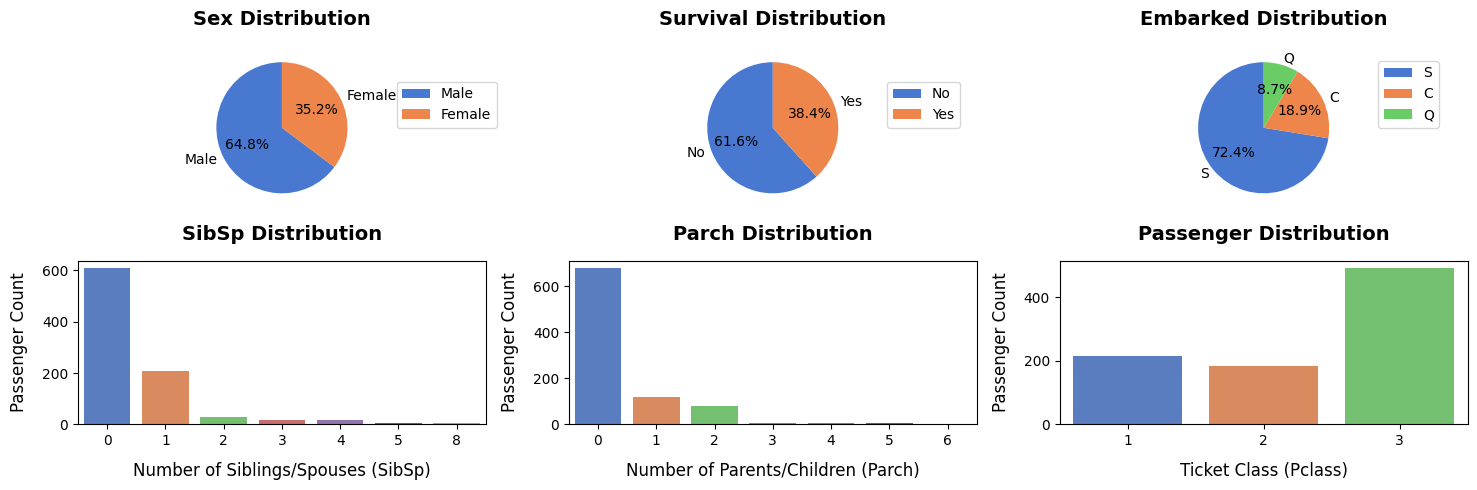

In [ ]:
import matplotlib.pyplot as plt

# Set global styles
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.labelpad'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

skewness = df['Fare'].skew()
plt.figure(figsize = (15,5))
sns.histplot(X_train['Fare'],kde = True)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title(f"Fare Distribution(Skewness: {skewness:.4f})")
plt.show()

colors = sns.color_palette('muted')
fig,axes = plt.subplots(2,3,figsize = (15,5))
axes =axes.flatten()
axes[0].pie(
    df['Sex'].value_counts(),
    labels = df['Sex'].str.title().value_counts().index,
    autopct = '%1.1f%%',
    colors = colors,
    startangle = 90
)
axes[0].legend(loc=(1.2, 0.5))
axes[0].set_title("Sex Distribution")

axes[1].pie(
    df['Survived'].value_counts(),
    labels = df['Survived'].map(lambda x:"No" if x==0 else 'Yes').value_counts().index,
    autopct = '%1.1f%%',
    colors = colors,
    startangle = 90)
axes[1].legend(loc=(1.2, 0.5))
axes[1].set_title("Survival Distribution")

axes[2].pie(
    df['Embarked'].value_counts(),
    labels = df['Embarked'].value_counts().index,
    autopct = '%1.1f%%',
    colors = colors,
    startangle = 90)
axes[2].legend(loc=(1.2, 0.5))
axes[2].set_title("Embarked Distribution")

sns.countplot(
    x = 'SibSp',
    data = df,
    ax = axes[3],
    palette = colors,
    )
axes[3].set(
    xlabel='Number of Siblings/Spouses (SibSp)',
    ylabel='Passenger Count',
    title='SibSp Distribution'
)

sns.countplot(
    x = 'Parch',
    data = df,
    ax = axes[4],
    palette = colors,
    )
axes[4].set(
    xlabel='Number of Parents/Children (Parch)',
    ylabel='Passenger Count',
    title='Parch Distribution'
)
sns.countplot(
    x = 'Pclass',
    data = df,
    ax = axes[5],
    palette = colors,
    )
axes[5].set(
    xlabel='Ticket Class (Pclass)',
    ylabel='Passenger Count',
    title='Passenger Distribution'
)

plt.tight_layout()
plt.show()

**Observations:**

*   In the Titanic dataset, the bar chart showing the distribution of the 'SibSp' (siblings/spouses) category reveals that most passengers did not have siblings with them.
*   Similarly, most passengers were not accompanied by their parents.
*   The most economical tickets were sold in the highest numbers.
*   The histogram for the "Fare" column shows a highly skewed distribution; most values fall within the 10-20 range. To handle this highly skewed data, we can use a power transformation-specifically, the "Yeo-Johnson" method. This method helps pull large values toward the center, making it highly suitable for these columns.




# Part 3 : Build a Neural Network

In [ ]:
import tensorflow as tf
def get_model(shape,n_layers = [32,16,8],dp_value = 0.4,seed = SEED):
    inp = tf.keras.layers.Input(shape=(shape,))
    x = inp
    for n_neurons in n_layers:
        x = tf.keras.layers.Dense(n_neurons, activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(dp_value,seed = seed)(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inp,out)
    return model

# Part 4 : Model Training

In [ ]:
BATCHS_IZE = 8
EPOCHS = 100
LR_RATE = 0.0008
LOSS_FUNC = tf.keras.losses.BinaryCrossentropy()
OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=LR_RATE)
METRICS = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    ]



In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
model = get_model(X_train_processed.shape[1])
model.compile(optimizer=OPTIMIZER, loss=LOSS_FUNC, metrics=METRICS)
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    batch_size=BATCHS_IZE,
    epochs=EPOCHS,
)


Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5602 - loss: 0.9058 - val_accuracy: 0.6343 - val_loss: 0.7352
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5361 - loss: 0.8976 - val_accuracy: 0.6493 - val_loss: 0.6987
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5923 - loss: 0.7626 - val_accuracy: 0.6493 - val_loss: 0.6843
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6148 - loss: 0.7348 - val_accuracy: 0.6418 - val_loss: 0.6569
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6164 - loss: 0.7583 - val_accuracy: 0.6418 - val_loss: 0.6402
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6533 - loss: 0.7134 - val_accuracy: 0.6418 - val_loss: 0.6209
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6661 - loss: 0.6476 - val_accuracy: 0.6493 - val_loss: 0.6109
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6709 - loss: 0.6420 - val_accuracy: 0.6940 -

In [ ]:
model.evaluate(X_test_processed,y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8433 - loss: 0.4220 


[0.4219822883605957, 0.8432835936546326]

# Part 5 : Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

In [ ]:
y_pred = model.predict(X_test_processed)
y_pred = (y_pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [ ]:
print(f"Accuracy: {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall: {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test,y_pred):.4f}")

Accuracy: 0.8433
Precision: 0.8039
Recall: 0.7885
F1 Score: 0.7961


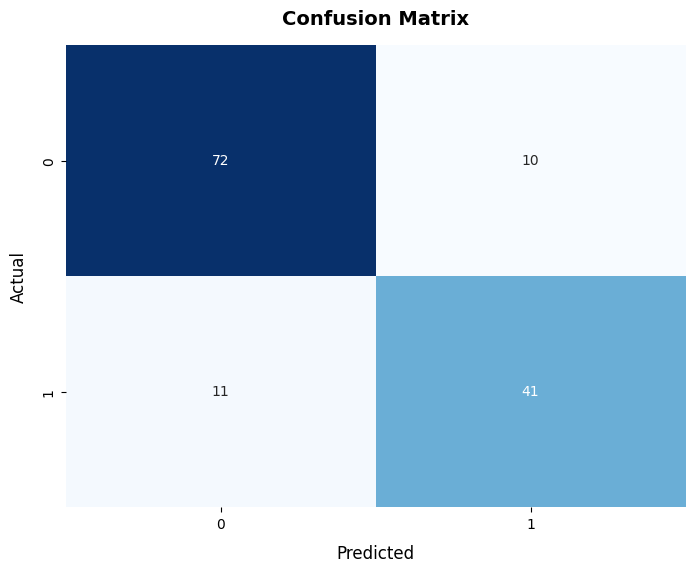

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Questions

* **Question 1**

**Is accuracy alone sufficient to judge this model? Why or why not?**
Answer: No, its not enough. eventhough it is 84% accurte model. Since class is imbalanced (Non-survival is 62%, and survival is 38%). we  need to focus on precision and recall majorly for unseen dataset.
* **Question 2**

**What does the confusion matrix tell you?**

    * **True Negatives (TN): 72** — The model correctly predicted the negative class 72 times.
    * **False Positives (FP): 11** — The model incorrectly predicted 11 actual negative instances as positive (**Type I error**).
    * **False Negatives (FN): 10** — The model incorrectly predicted 10 actual positive instances as negative (**Type II error**).
    * **True Positives (TP): 41** — The model correctly predicted the positive class 41 times.

* **Question 3**

**Which metric would you prioritize if missing a positive prediction was particularly costly?Explain.**

Recall. We need to minimize false negatives (FN) when missing a positive prediction would result in a significant loss. Recall measures the proportion of actual positive instances correctly identified by the model. Therefore, prioritizing recall helps reduce false negatives and ensures that more actual positive instances are detected.

# Part 6: Training Analysis

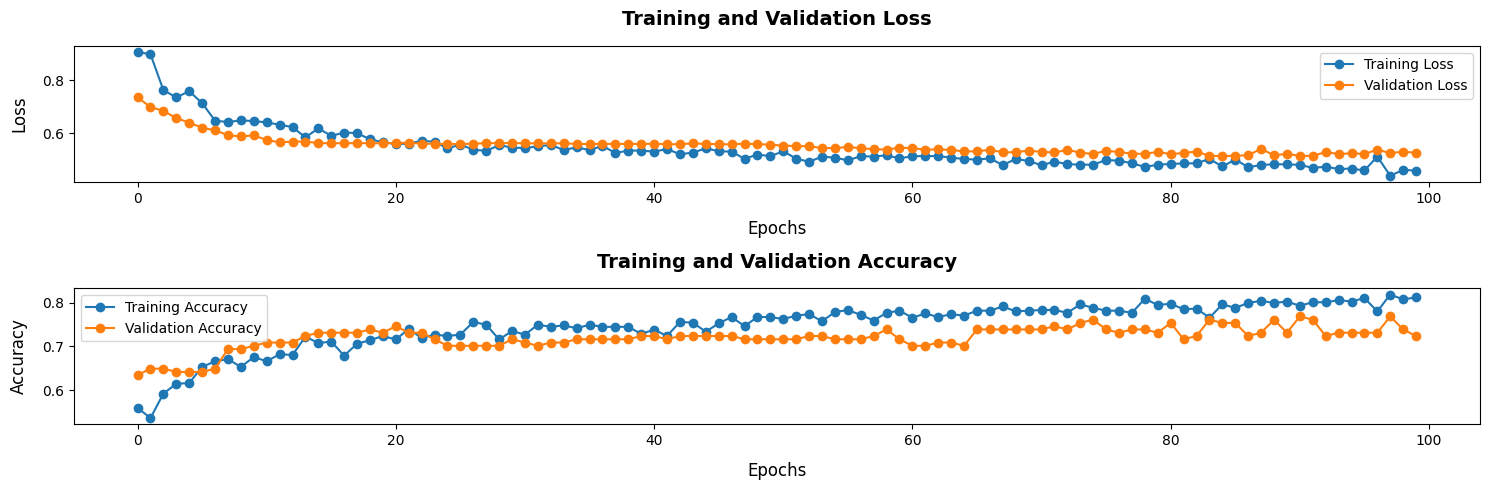

In [ ]:
fig,axes = plt.subplots(2,1,figsize = (15,5))

axes[0].plot(range(EPOCHS),history.history['loss'],"-o", label='Training Loss')
axes[0].plot(range(EPOCHS),history.history['val_loss'],"-o", label='Validation Loss')
axes[0].legend()
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[1].plot(range(EPOCHS),history.history['accuracy'],"-o", label='Training Accuracy')
axes[1].plot(range(EPOCHS),history.history['val_accuracy'],"-o", label='Validation Accuracy')
axes[1].legend()
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
plt.tight_layout()
plt.show()

**Observations:**

*   After approximately 70–80 epochs, this model exhibits slight overfitting, as the training accuracy continues to rise while the validation accuracy remains relatively stable or declines.
*   A simpler model incorporating appropriate dropout and a moderate learning rate would likely suffice to improve generalization and reduce overfitting.

# Part 7: Small Experiment

## Experiment A

In [ ]:
results = {}
metrics_table = []

exp_list = [
    [32,16], # two layers
    [32],    # single layer
]

for n in exp_list:
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    LOSS_FUNC = tf.keras.losses.BinaryCrossentropy()
    OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=LR_RATE)
    METRICS = [
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        ]
    exp_model = get_model(X_train_processed.shape[1],n)
    exp_model.compile(optimizer=OPTIMIZER, loss=LOSS_FUNC, metrics=METRICS)
    results[len(n)] = exp_model.fit(
        X_train_processed, y_train,
        validation_data=(X_val_processed, y_val),
        batch_size=BATCHS_IZE,
        epochs=EPOCHS,
        verbose = 0,
    )
    h = results[len(n)]
    tmp_test_loss, tmp_test_acc = exp_model.evaluate(X_test_processed, y_test, verbose=0)
    tmp_traing_loss, tmp_training_acc = exp_model.evaluate(X_train_processed, y_train, verbose=0)
    tmp_val_loss, tmp_val_acc = exp_model.evaluate(X_val_processed, y_val, verbose=0)

    # Get predictions on the test set for precision/recall/F1
    y_prob = exp_model.predict(X_test_processed, verbose=0)
    y_pred = (y_prob > 0.5).astype(int)

    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)

    print(
        f"{n} Hidden Layer | "
        f"Training Loss: {tmp_traing_loss:.4f} | "
        f"Training Acc: {tmp_training_acc:.4f} | "
        f"Validation Loss: {tmp_val_loss:.4f} | "
        f"Validation Acc: {tmp_val_acc:.4f} | "
        f"Test Acc: {tmp_test_acc:.4f} | "
        f"Test Precision: {test_precision:.4f} | "
        f"Test Recall: {test_recall:.4f} | "
        f"Test F1: {test_f1:.4f}"
    )

    metrics_table.append({
        'Architecture': f"{len(n)} Hidden Layer{'s' if len(n) > 1 else ''} {n}",
        'Test Accuracy': round(tmp_test_acc, 4),
        'Test Precision': round(test_precision, 4),
        'Test Recall': round(test_recall, 4),
        'Test F1': round(test_f1, 4),
    })

    del exp_model
    import gc; gc.collect()

comparison_df = pd.DataFrame(metrics_table)
display(comparison_df)

[32, 16] Hidden Layer | Training Loss: 0.4057 | Training Acc: 0.8234 | Validation Loss: 0.5119 | Validation Acc: 0.7761 | Test Acc: 0.8209 | Test Precision: 0.8182 | Test Recall: 0.6923 | Test F1: 0.7500
[32] Hidden Layer | Training Loss: 0.3874 | Training Acc: 0.8443 | Validation Loss: 0.5336 | Validation Acc: 0.7836 | Test Acc: 0.8284 | Test Precision: 0.7736 | Test Recall: 0.7885 | Test F1: 0.7810


,Architecture,Test Accuracy,Test Precision,Test Recall,Test F1
0,"2 Hidden Layers [32, 16]",0.8209,0.8182,0.6923,0.750
1,1 Hidden Layer [32],0.8284,0.7736,0.7885,0.781


**Oberservations:**


* Although the **2-hidden-layer model** has a low validation loss (0.5119), it exhibits a lower Test F1 score 0.7500, indicating weak recall capability.
* The **1-hidden-layer model** achieved superior Test Accuracy (0.8284), Recall (0.7885), and F1 (0.7810) scores, demonstrating better overall generalization capability.

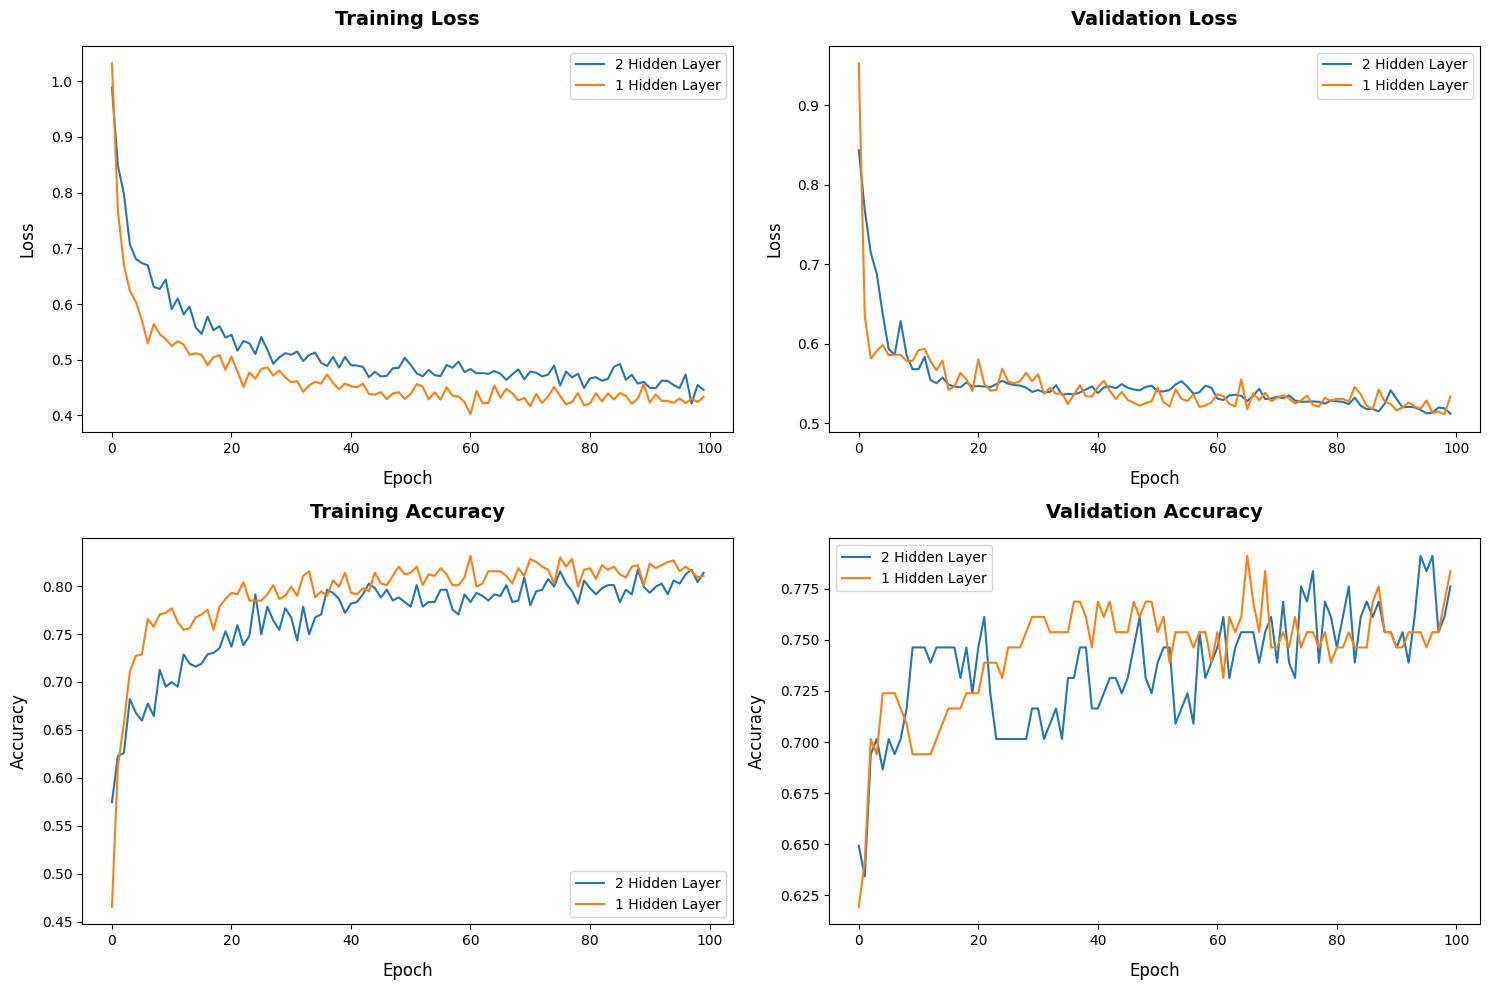

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plots = [
    ('loss', 'Training Loss'),
    ('val_loss', 'Validation Loss'),
    ('accuracy', 'Training Accuracy'),
    ('val_accuracy', 'Validation Accuracy')
]

for ax, (metric, title) in zip(axes.flat, plots):
    for n, h in results.items():
        ax.plot(h.history[metric], label=f'{n} Hidden Layer')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss' if 'loss' in metric else 'Accuracy')
    ax.legend()

plt.tight_layout()
plt.show()

**Observations:**
*  **The single hidden-layer model** exhibits lower training loss and higher training accuracy, while also achieving slightly better overall validation accuracy and lower validation loss.


*  **The double hidden-layer model** does not offer a clear improvement in validation performance, indicating that the simpler single hidden-layer architecture generalizes slightly better.

# Part 8 : Prediction

In [ ]:
# samples_idx = np.random.choice(X_test.index,5)
samples_idx = [459, 198, 558,  16, 532]

In [ ]:
print("Samples:")
samples = X_test.loc[samples_idx]
actual = y_test.loc[samples_idx]
display(samples,actual)

Samples:


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
459,3,male,NaN,0,0,7.7500,NaN,Q
198,3,female,NaN,0,0,7.7500,NaN,Q
558,1,female,39.0,1,1,79.6500,E67,S
16,3,male,2.0,4,1,29.1250,NaN,Q
532,3,male,17.0,1,1,7.2292,NaN,C


,Survived
459,0
198,1
558,1
16,0
532,0


In [ ]:
samples_processes = preprocessor.transform(X_test.loc[samples_idx])
prob = model.predict(samples_processes)
pred = (prob > 0.5).astype(int)

results_df = samples.copy()
results_df['Actual'] = actual.values
results_df['Predicted'] = pred
results_df['Probability'] = prob
display(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Actual,Predicted,Probability
459,3,male,NaN,0,0,7.7500,NaN,Q,0,0,0.145716
198,3,female,NaN,0,0,7.7500,NaN,Q,1,1,0.744729
558,1,female,39.0,1,1,79.6500,E67,S,1,1,0.864963
16,3,male,2.0,4,1,29.1250,NaN,Q,0,0,0.121341
532,3,male,17.0,1,1,7.2292,NaN,C,0,0,0.141848


**Observations:**

* **Sample 459**: The passenger is **3rd class**, **male**, with **missing age**, no siblings/parents aboard, and a low fare of **7.75**. The combination of **male sex, 3rd-class status, and low fare** is associated with lower survival probability. The model correctly predicted **non-survival (0)** with a probability of **0.145**.

* **Sample 198**: This passenger is a **3rd-class female** with **missing age**, no siblings/parents aboard, and a low fare of **7.75**. Although the **3rd-class status and low fare** may reduce the likelihood of survival, being **female** is a strong positive factor. The model correctly predicted **survival (1)** with a probability of **0.744**.

* **Sample 558**: This passenger is a **1st-class female, age 39**, traveling with **1 sibling/spouse and 1 parent/child**, with a high fare of **79.65** and an **E-class cabin**. The combination of **female sex, 1st-class status, and high fare** strongly favors survival. The model correctly predicted **survival (1)** with high confidence (**0.864**).

* **Sample 16**: This passenger is a **3rd-class male, age 2**, traveling with **4 siblings/spouses and 1 parent/child**, with a fare of **29.13**. Although the passenger is very young, the **male sex and 3rd-class status** are associated with lower survival probability. The model correctly predicted **non-survival (0)** with high confidence (**0.121**).

* **Sample 532**: This passenger is a **3rd-class male, age 17**, traveling with **1 sibling/spouse and 1 parent/child**, with a low fare of **7.23** and embarked at **Cherbourg (C)**. The combination of **male sex, 3rd-class status, and low fare** contributes toward a lower survival probability. The model correctly predicted **non-survival (0)** with a probability of **0.141**.

**Overall:** The predictions are consistent with major Titanic survival patterns, particularly **Sex, Pclass, and Fare**. **Female passengers and 1st-class passengers generally receive higher survival probabilities**, whereas **male and 3rd-class passengers tend to receive lower probabilities**. In these five unseen samples, the model correctly classified **all 5 passengers (100%)**, although this small sample should not be considered representative of the model's overall performance.


# Bonus : Optional


## Bonus 3 : Explainability

In [ ]:
import shap
import numpy as np
def predict_fn(X_processed):
    return model.predict(X_processed, verbose=0).ravel()
background = preprocessor.transform(X_train[:100])
explainer = shap.Explainer(
    predict_fn,
    background
)
shap_values = explainer(preprocessor.transform(X_val[:100]),)

PermutationExplainer explainer: 101it [05:56,  3.56s/it]


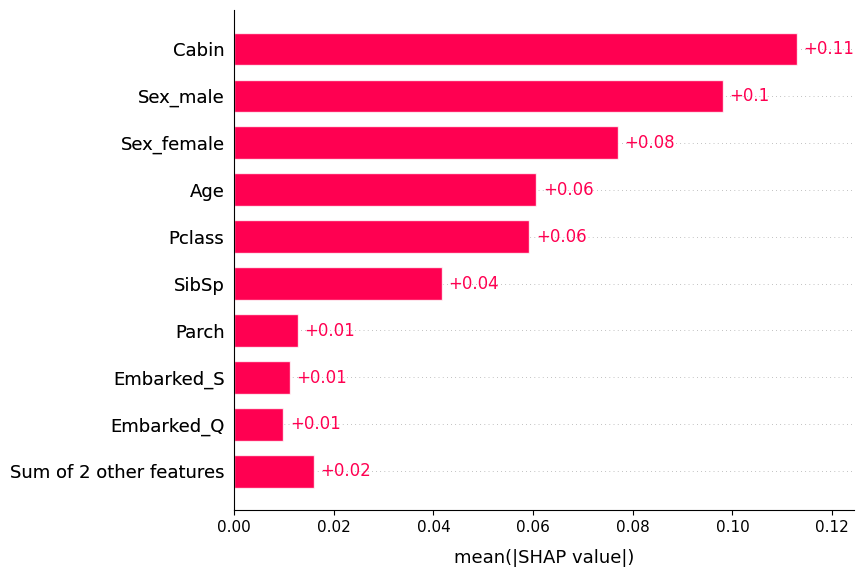

In [ ]:
shap_values = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_val_processed[:100],
    feature_names=[i.split('__')[-1] for i in preprocessor.get_feature_names_out()]
)

shap.plots.bar(shap_values)

**Observations:**
* **Sex_male** and **Cabin** exert the strongest influence on the model's predictions; these are followed by **Sex_female**, **Age**, and **Pclass**.
* Overall, the model relies primarily on **Sex**, **Cabin**, **Age**, and **Pclass** to predict survival.